# **Building and Training a Feedforward Neural Network for Language Modeling**

This project explores the use of Feedforward Neural Networks (FNNs) in language modeling. The primary objective is to build a neural network that learns word relationships and generates meaningful text sequences. The implementation is done using PyTorch, covering key aspects of Natural Language Processing (NLP), such as:
* Tokenization & Indexing: Converting text into numerical representations.
* Embedding Layers: Mapping words to dense vector representations for efficient learning.
* Context-Target Pair Generation (N-grams): Structuring training data for sequence prediction.
* Multi-Class Neural Network: Designing a model to predict the next word in a sequence.

The training process includes optimizing the model with loss functions and backpropagation techniques to improve accuracy and coherence in text generation. By the end of the project, you will have a working FNN-based language model capable of generating text sequences.



# **Objectives**

After completing this lab, you will be able to:

 - Implement a feedforward neural network using the PyTorch framework, including embedding layers, for language modeling tasks.
 - Fine-tune the output layer of the neural network for optimal performance in text generation.
 - Apply various training strategies and fundamental Natural Language Processing (NLP) techniques, such as tokenization and sequence analysis, to improve text generation.


#### Import Libraries

In [2]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import torch
import re
import string
from nltk.tokenize import word_tokenize


## Feedforward Neural Networks (FNNs) for language models

FNNs, or Multi-Layer Perceptrons, serve as the foundational components for comprehending neural networks in natural language processing (NLP). In NLP tasks, FNNs process textual data by transforming it into numerical vectors known as embeddings. Subsequently, these embeddings are input to the network to predict language facets, such as the upcoming word in a sentence or the sentiment of a text.

Let's consider the following song lyrics for our analysis.


In [3]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

### Data Preprocessing

In [4]:
def preprocess_string(s):
    
    # Remove all non-word characters (everything except letters and numbers)
    # \w matches any word character (letters, numbers, and underscores)
    # \s matches any whitespace characters
    # ^ inside [] negates the selection, so [^\w\s] matches anything that's NOT a word character or whitespace.
    s = re.sub(r"[^\w\s]",'', s)
    
    # Remove all whitespace characters (spaces, tabs, newlines)
    # \s+ matches one or more whitespace characters.
    s = re.sub(r"[\s+]",'', s)
    
    # Remove all digits (0-9)
    # \d matches any digit character.
    s = re.sub(r"[\d]",'',s)
    
    return s

In [5]:
def preprocessing(words):
    
    tokens = word_tokenize(words)
    tokens_preprocessed = [preprocess_string(token) for token in tokens]
    
    return [word.lower() for word in tokens_preprocessed if len(word) !=0 and
            (word not in string.punctuation)]
        

In [6]:
## tokenized the song
tokens = preprocessing(song)
tokens

['we',
 'are',
 'no',
 'strangers',
 'to',
 'love',
 'you',
 'know',
 'the',
 'rules',
 'and',
 'so',
 'do',
 'i',
 'a',
 'full',
 'commitments',
 'what',
 'im',
 'thinking',
 'of',
 'you',
 'wouldnt',
 'get',
 'this',
 'from',
 'any',
 'other',
 'guy',
 'i',
 'just',
 'wan',
 'na',
 'tell',
 'you',
 'how',
 'im',
 'feeling',
 'got',
 'ta',
 'make',
 'you',
 'understand',
 'never',
 'gon',
 'na',
 'give',
 'you',
 'up',
 'never',
 'gon',
 'na',
 'let',
 'you',
 'down',
 'never',
 'gon',
 'na',
 'run',
 'around',
 'and',
 'desert',
 'you',
 'never',
 'gon',
 'na',
 'make',
 'you',
 'cry',
 'never',
 'gon',
 'na',
 'say',
 'goodbye',
 'never',
 'gon',
 'na',
 'tell',
 'a',
 'lie',
 'and',
 'hurt',
 'you',
 'weve',
 'known',
 'each',
 'other',
 'for',
 'so',
 'long',
 'your',
 'hearts',
 'been',
 'aching',
 'but',
 'youre',
 'too',
 'shy',
 'to',
 'say',
 'it',
 'inside',
 'we',
 'both',
 'know',
 'whats',
 'been',
 'going',
 'on',
 'we',
 'know',
 'the',
 'game',
 'and',
 'were',
 'gon',

### Vocabulary 

In [7]:
vocab = set(tokens)
vocab

{'a',
 'aching',
 'and',
 'any',
 'are',
 'around',
 'ask',
 'been',
 'blind',
 'both',
 'but',
 'commitments',
 'cry',
 'desert',
 'do',
 'dont',
 'down',
 'each',
 'feeling',
 'for',
 'from',
 'full',
 'game',
 'get',
 'give',
 'going',
 'gon',
 'goodbye',
 'got',
 'guy',
 'hearts',
 'how',
 'hurt',
 'i',
 'if',
 'im',
 'inside',
 'it',
 'just',
 'know',
 'known',
 'let',
 'lie',
 'long',
 'love',
 'make',
 'me',
 'na',
 'never',
 'no',
 'of',
 'on',
 'other',
 'play',
 'rules',
 'run',
 'say',
 'see',
 'shy',
 'so',
 'strangers',
 'ta',
 'tell',
 'the',
 'thinking',
 'this',
 'to',
 'too',
 'understand',
 'up',
 'wan',
 'we',
 'were',
 'weve',
 'what',
 'whats',
 'wouldnt',
 'you',
 'your',
 'youre'}

In [8]:
text_pipeline_old = lambda x: vocab(word_tokenize(x))
text_pipeline_old(song)[0:10]


TypeError: 'set' object is not callable

**For this error we can callable sets, because vocab is created using sets instead of build_vocab so we have to define get_tokenizer uisng torchtext**

In [9]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

In [11]:
tokenizer = get_tokenizer("basic_english")
        
vocabulary = build_vocab_from_iterator(map(tokenizer,song.split()),specials=["<unk>"])
vocabulary.set_default_index(vocabulary["<unk>"])

In [12]:
print(vocabulary(tokens)[0:10])

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]


In [13]:
# set vocabulary index (that converts raw text into indexes)
text_pipeline = lambda x: vocabulary(tokenizer(x))
text_pipeline(song)[0:10]

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]

In [14]:
index_to_token = vocabulary.get_itos()
index_to_token[58]

'are'

## Embdedding Layer

An embedding layer is a crucial element in natural language processing (NLP) and neural networks designed for sequential data. It serves to convert categorical variables, like words or discrete indexes representing tokens, into continuous vectors. This transformation facilitates training and enables the network to learn meaningful relationships among words.

Let’s consider a different vocabulary:

Vocabulary: {cat, dog, bird, fish}

Each word is assigned a unique index:

Indices: {0, 1, 2, 3}

When using an embedding layer, each index is mapped to a continuous vector (randomly initialized at first):

Vector for index 0 (cat): [0.5, -0.2, 0.1]
Vector for index 1 (dog): [-0.3, 0.9, 0.4]
Vector for index 2 (bird): [0.7, 0.3, -0.6]
Vector for index 3 (fish): [-0.1, 0.2, 0.8]

In [15]:
import torch.nn as nn 

In [16]:

def gen_embeddeing(vocab):
    
    # define number of dimesions
    embeded_dim = 20
    # define vocabulary size
    vocab_size = len(vocab)
    
    # define an embedding layer
    embedding = nn.Embedding(vocab_size, embeded_dim)
    
    return embedding
    


**Embeddings**: Obtain the embedding for the first word with index 0 or 1. Don't forget that you have to convert the input into a tensor. The embeddings are initially initialized randomly, but as the model undergoes training, words with similar meanings gradually come to cluster closer together


In [17]:
embeddings = gen_embeddeing(vocabulary)
embeddings

Embedding(79, 20)

In [18]:
for n in range(2): 
    embedding=embeddings(torch.tensor(n))
    print("word",index_to_token[n])
    print("index",n)
    print( "embedding", embedding)
    print("embedding shape", embedding.shape)

word <unk>
index 0
embedding tensor([-1.4601,  1.7450,  0.2324, -0.5643, -1.3471,  0.9295, -0.8267, -0.8802,
        -1.0137, -0.3343,  0.6266, -1.1276,  0.4430,  0.5284,  1.5259,  0.1445,
         0.2650, -0.6662,  2.3931, -0.2393], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])
word gonna
index 1
embedding tensor([-0.9370,  1.5285, -0.5192, -1.6354,  1.1284, -0.4718, -0.3394,  0.0099,
         0.4014,  1.4519,  0.0467,  2.4463, -0.9590,  0.4568, -1.3155,  0.2072,
         0.5771,  0.0623, -3.0038,  2.0275], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])


These vectors will serve as inputs for the next layer.
### Generating context-target pairs (n-grams)

Organize words within a variable-size context using the following approach: Each word is denoted by 'i'. 
To establish the context, simply subtract 'j'. The size of the context is determined by the value of``CONTEXT_SIZE``.


In [19]:
context_size = 2

def gen_ngrams(tokens,context_size):
    
    endsize = len(tokens)
    n_grams = [([tokens[i-j-1] for j in range(context_size)],tokens[i])
               for i in range(context_size, endsize)] 
    
    return n_grams

In [20]:
gen_ngrams(tokens,2)

[(['are', 'we'], 'no'),
 (['no', 'are'], 'strangers'),
 (['strangers', 'no'], 'to'),
 (['to', 'strangers'], 'love'),
 (['love', 'to'], 'you'),
 (['you', 'love'], 'know'),
 (['know', 'you'], 'the'),
 (['the', 'know'], 'rules'),
 (['rules', 'the'], 'and'),
 (['and', 'rules'], 'so'),
 (['so', 'and'], 'do'),
 (['do', 'so'], 'i'),
 (['i', 'do'], 'a'),
 (['a', 'i'], 'full'),
 (['full', 'a'], 'commitments'),
 (['commitments', 'full'], 'what'),
 (['what', 'commitments'], 'im'),
 (['im', 'what'], 'thinking'),
 (['thinking', 'im'], 'of'),
 (['of', 'thinking'], 'you'),
 (['you', 'of'], 'wouldnt'),
 (['wouldnt', 'you'], 'get'),
 (['get', 'wouldnt'], 'this'),
 (['this', 'get'], 'from'),
 (['from', 'this'], 'any'),
 (['any', 'from'], 'other'),
 (['other', 'any'], 'guy'),
 (['guy', 'other'], 'i'),
 (['i', 'guy'], 'just'),
 (['just', 'i'], 'wan'),
 (['wan', 'just'], 'na'),
 (['na', 'wan'], 'tell'),
 (['tell', 'na'], 'you'),
 (['you', 'tell'], 'how'),
 (['how', 'you'], 'im'),
 (['im', 'how'], 'feeling'

Output the first element, which results in a tuple. The initial element represents the context, and the index indicates the following word.


In [21]:
ngrams=gen_ngrams(tokens,2)
context, target=ngrams[0]
print("context",context,"target",target)
print("context index",vocabulary(context),"target index",vocabulary([target]))

context ['are', 'we'] target no
context index [58, 21] target index [70]


The Core Reason: Flattening Concatenated Embeddings
In an n-gram model, you have CONTEXT_SIZE number of token embeddings, and each embedding is a vector of size embedding_dim. Before passing them to the linear layer, you concatenate (flatten) all those embeddings into a single 1D vector.

word_1 → [e1, e2, ..., e20]        # 20 values
word_2 → [e1, e2, ..., e20]        # 20 values  
word_3 → [e1, e2, ..., e20]        # 20 values

That's embedding_dim * CONTEXT_SIZE = 20 * 3 = 60 values — which is exactly why the linear layer needs embedding_dim * CONTEXT_SIZE as its input dimension.

### Linear Layer Define

In [22]:
embeded_dims = 20
linear_layer = nn.Linear(embeded_dims * context_size, 128)

In [23]:
my_embdedding = embeddings(torch.tensor(vocabulary(context)))
my_embdedding

tensor([[-0.7918, -0.4333,  0.9920, -0.1757,  0.2316, -2.2816, -0.0763, -0.6726,
         -0.2495, -0.4268, -0.9486, -0.9710,  1.5393,  1.5818, -0.2932, -0.0382,
          0.8347,  0.6146, -1.0608,  1.0761],
        [-0.2857,  0.1946, -0.8330,  0.9090, -0.5115,  1.2833, -1.7932,  0.9014,
          0.3759,  0.7129,  1.8963, -0.7074, -1.9767, -0.0638,  0.6431, -0.2303,
         -0.5126, -0.4034,  0.6826,  0.9132]], grad_fn=<EmbeddingBackward0>)

**We have to flattern the size before feed to the linear layer**

In [24]:
my_embdedding = my_embdedding.reshape(1,-1)
my_embdedding.shape

torch.Size([1, 40])

In [25]:
linear_layer(my_embdedding)

tensor([[-0.1024, -0.5890,  0.0492,  0.1412,  0.2337,  0.1702,  0.1874, -0.1527,
          0.1017,  0.4132,  0.6254, -0.0756,  0.2994,  0.4002, -0.5659, -0.1361,
         -0.3368, -1.2930, -0.4171,  0.7793, -0.0904, -0.0701,  0.1980, -0.2911,
         -0.0103,  0.2396, -0.3642,  0.2169, -0.2220,  0.2958, -0.5074, -0.2441,
          0.4393,  0.1902, -0.0927,  0.5576,  0.4921,  0.3960,  0.7555,  0.1787,
          0.1045, -0.7371,  0.5816,  0.8102,  0.3007, -0.3881, -0.5072, -0.4401,
         -0.5969,  0.1061, -0.0335,  0.4877, -0.2529, -1.1825, -0.2326, -0.9820,
          1.0701,  0.7802, -0.5598, -0.0729, -0.4348, -0.5071, -0.3119,  0.1700,
          0.6598, -0.1466,  0.0237, -0.3729,  0.6374, -0.8442,  0.9327, -0.3804,
          0.1234, -0.3037, -0.4313, -0.1991, -0.7232,  0.3570,  0.4369, -0.9660,
         -0.1899,  0.8848, -0.6708,  0.7037,  0.3016, -0.4102, -0.6960, -0.5038,
         -0.6383,  0.5098, -0.7801,  0.3562, -0.0113, -0.3532,  0.0858, -0.1545,
         -1.2641, -0.8514, -

## **Batch Function Definition**

In [26]:
from torch.utils.data import DataLoader

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 10
context_size = 3
embeded_dims = 20

def collate_func(batch):
    
    context, target = [],[]
    batch_size = len(batch)
    
    for i in range(context_size, batch_size):
        
        target.append(vocabulary([batch[i]]))
        context.append(vocabulary([batch[i-j-1]for j in range(context_size)])) 
        
        
        
    return torch.tensor(context).to(device), torch.tensor(target).to(device).reshape(-1)

Similarly, it's important to highlight that the size of the last batch could deviate from that of the earlier batches. To tackle this, the approach involves adjusting the final batch to conform to the specified batch size, ensuring it becomes a multiple of the predetermined size. When necessary, you'll employ padding techniques to achieve this harmonization. One approach you'll use is appending the beginning of the song to the end of the batch.


In [28]:
Padding=batch_size-len(tokens)%batch_size
tokens_pad=tokens+tokens[0:Padding]

### **Data Loader**

In [29]:
data_loader = DataLoader(
    tokens_pad, shuffle=True, batch_size=batch_size, collate_fn=collate_func
)

## Multi-class neural network

You have developed a PyTorch class for a multi-class neural network. The network's output is the probability of the next word within a given context. Therefore, the number of classes corresponds to the count of distinct words. The initial layer consists of embeddings, and in addition to the final layer, an extra hidden layer is incorporated.


In [30]:
import torch.nn.functional as F

In [31]:
class NGramLanuageModel (nn.Module):
    
    def __init__(self, vocab_size, context_size, embeded_dims):
        super(NGramLanuageModel,self).__init__()
        
        # initializing class variables
        self.context_size = context_size
        self.embedded_dim = embeded_dims
        
        # define embdedding function
        self.embeddings = nn.Embedding(vocab_size, self.embedded_dim)
        
        # Fully connected hidden layer: Maps the concatenated embeddings to a 128-dimensional space
        self.linear_layer_1 = nn.Linear(self.embedded_dim * self.context_size, 128)
        
        # Output layer: Maps the hidden layer output to vocabulary size (probability distribution over words)
        self.linear_layer_output = nn.Linear(128, vocab_size)
        
    def forward(self, input):
        
        # Convert input word indices into dense vectors using the embedding layer    
        embed = self.embeddings(input) # Shape: (batch_size, context_size, embedding_dim)
        
        # Reshape the embeddings into a single vector per input sample
        embed = torch.reshape(embed,(-1, self.context_size* self.embedded_dim))
        
        # Apply first fully connected layer with ReLU activation
        out_1 = F.relu(self.linear_layer_1(embed))
        
        # Apply second fully connected layer to generate vocabulary-size logits
        out_2 = self.linear_layer_output(out_1)
        
        return out_2 

### Create a Instance of Model

In [32]:
model = NGramLanuageModel(len(vocabulary),context_size,embeded_dims).to(device)

Retrieve Samples from the Dataloader to Model

In [33]:
data_iter = iter(data_loader)
context, target = next(data_iter)
print("context:\n", context)
print("target:\n", target)

model_target = model(context)
print("Model Target:\n", model_target)

context:
 tensor([[ 5,  2, 22],
        [ 3,  5,  2],
        [ 0,  3,  5],
        [ 5,  0,  3],
        [43,  5,  0],
        [ 8, 43,  5],
        [ 3,  8, 43]])
target:
 tensor([ 3,  0,  5, 43,  8,  3,  3])
Model Target:
 tensor([[-3.8096e-01,  2.8998e-01,  1.1279e-01, -3.1253e-02,  9.9370e-02,
         -9.9068e-02, -5.4152e-02, -2.8388e-01, -1.3590e-01,  1.3994e-01,
         -2.5541e-02,  1.4449e-01,  2.7188e-01,  7.3217e-01,  7.0481e-03,
         -9.6015e-02,  1.2977e-01, -2.1005e-01,  4.6228e-01,  5.4861e-01,
         -2.1745e-01, -7.1855e-02,  2.6560e-01,  3.3454e-01,  4.6163e-01,
         -1.7868e-03, -1.7499e-01,  1.8763e-01, -6.5899e-02, -1.6378e-01,
         -1.5306e-01, -2.1854e-02,  1.2138e-01, -2.0315e-01, -3.4061e-01,
          6.1807e-02, -3.4292e-01, -7.1636e-02,  2.2073e-01, -1.1163e-01,
          5.0870e-02,  1.2227e-02,  1.6607e-01,  5.3551e-01, -1.1036e-01,
          1.0549e-01,  7.5507e-02,  1.6895e-01, -8.9320e-02, -2.2336e-02,
          1.0909e-01,  2.1994e-01,

While the model remains untrained, analyzing the output can provide us with a clearer understanding. In the output, the first dimension corresponds to the batch size, while the second dimension represents the probability associated with each class.


In [34]:
model_target.shape

torch.Size([7, 79])

Find the index with the highest probability.


In [35]:
predict_index = torch.argmax(model_target,1)
predict_index

tensor([13, 43, 58, 22,  9, 55, 58])

In [36]:
[index_to_token[i.item()] for i in predict_index]

['give', 'inside', 'are', 'been', 'around', 'whats', 'are']

Create a function that accomplishes the same task for the tokens.


In [75]:
def write_song(model, my_song, num_of_words = 100):
    
    # Get the mapping from index to word for decoding predictions
    index_to_tokens = vocabulary.get_itos()
    generate_tokens = my_song.split()
    
    # Loop to generate the desired number of words
    for i in range(num_of_words):
        
        with torch.no_grad():
            # Build context from the LAST context_size words of generated text
            context_word = generate_tokens [-context_size:]
            context = torch.tensor(
                vocabulary(context_word)
            ).to(device)
            
            temperature = 0.8
            # Predict the next word by selecting the word with the highest probability
            logits = model(context)
            probs = torch.softmax(logits / temperature, dim=-1)  # temperature=0.8 is a good start
            word_idx = torch.multinomial(probs, 1).item()
            
            # Append the predicted word to the generated text
            my_song += " " +  index_to_tokens[word_idx]
    
    return my_song 

In [76]:
import random

In [77]:
def pickrandomline(song):
    """
    Selects a random line from the given song text.

    This function splits the song into separate lines and randomly picks one of them.

    Parameters:
    song (str): The song lyrics as a multi-line string.

    Returns:
    str: A randomly selected line from the song.
    """
    
    # Split the song into individual lines
    lines = song.split("\n")  
    
    # Randomly select a line and remove leading/trailing whitespace
    selected_line = random.choice(lines).strip()
    
    return selected_line  # Return the randomly selected line

# Example usage:
selected_line = pickrandomline(song)  # Pick a random line from the song

# Generate a new song starting with the selected line
generated_song = write_song(model, selected_line)

# Print the generated lyrics
print(generated_song)


Never gonna tell a lie and hurt you inside let youre desert a too down let shy on from a on goodbye what each but me say dont <unk> blind im whats up if whats tell i dont tell rules commitments too on from how ask long how each just but wanna wouldnt so full been for both wanna been never down see and a of tell desert inside this say too shy down been what a never a each let im from play make aching <unk> whats been we run know i inside strangers understand tell inside no blind lie gotta a understand see on blind each


## Training

Training a language model involves a multi-step process that leverages training and testing data to optimize model performance. In the realm of Natural Language Processing (NLP), this process often employs various metrics to gauge a model's accuracy, such as perplexity or accuracy on unseen data. However, in the context of your current exploration, you will embark on a slightly different journey. Instead of relying solely on conventional NLP metrics, the focus shifts to manual inspection of the results. 

You have the cross entropy loss between input logits and target:


In [78]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR
from tqdm import tqdm

In [79]:
lanuage_model = NGramLanuageModel(len(vocabulary),context_size,embeded_dims)
criterion = nn.CrossEntropyLoss()
optimizer = SGD(lanuage_model.parameters(),lr=0.01)
scheduler = StepLR(optimizer,step_size=1.0, gamma=0.1)


You have developed a function dedicated to training the model using the supplied data loader. In addition to training the model, the function's output includes predictions for each epoch, spanning context for the next 100 words.


>**Note: Since the dataset used is relatively small and the model is trained for a limited number of epochs, the generated song may not always be fully coherent due to a restricted vocabulary. This example primarily serves to demonstrate the functionality of a feedforward neural network for language modeling.**


In [80]:
def model_train(model, dataloader, song, number_of_epochs = 100, show =10):
    
    my_loss = []
    
    for epoch in tqdm(range(number_of_epochs)):
        total_loss = 0
        my_song = ""
        
        for context, target in dataloader:
            model.zero_grad() # avoid accumaltion
            model_predict = model(context) # predict the output from the model
            loss = criterion(model_predict, target) # calculate the loss
            
            total_loss += loss.item() # accumulate the loss
            loss.backward() # loss send for backpropagation
            
            optimizer.step() # parameter weights update
            
        # Display progress and generate song at specified intervals
        if epoch%show ==0:
            selected_line = pickrandomline(song)
            my_song += "" + write_song(model, selected_line)
            
            print("Generated songs:\n", my_song)
        
        my_loss.append(total_loss/len(data_loader))
        
    return my_loss            
        
    

The following list will be used to store the loss for each model.


In [81]:
model_loss = []

In [82]:
trained_loss = model_train(lanuage_model,data_loader,song)

  3%|▎         | 3/100 [00:00<00:07, 12.21it/s]

Generated songs:
 Never gonna run around and desert you know hearts let feeling make rules play long for aching make you gonna around gonna long it hearts make shy gotta any never but your <unk> ask been full other around what love so understand you if thinking whats gonna too both no game known on tell youre gotta play are wouldnt any other you the cry it it were get known down desert never feeling hearts for are hurt and do and no hearts love just you no know of what known and give were were full around never cry a up full game other make hearts how play


 13%|█▎        | 13/100 [00:01<00:06, 12.99it/s]

Generated songs:
 Never gonna give you up cry give <unk> and <unk> <unk> up me never <unk> cry <unk> and hearts and no <unk> to you for never make were <unk> whats and <unk> guy you <unk> never desert never lie never we <unk> <unk> hurt aching <unk> give shy <unk> say you strangers whats <unk> give never so make cry <unk> give <unk> never never were for <unk> <unk> <unk> <unk> let never it you and for give you <unk> both <unk> say say we <unk> never this your other never you you never shy other you you <unk> each gotta wouldnt never i <unk> <unk>


 24%|██▍       | 24/100 [00:01<00:04, 16.31it/s]

...

 84%|████████▍ | 84/100 [00:04<00:00, 21.41it/s]

Generated songs:
 Never gonna make you cry feeling desert we <unk> and <unk> <unk> wouldnt <unk> know <unk> make run <unk> <unk> goodbye down never <unk> a <unk> <unk> <unk> <unk> know the tell tell <unk> <unk> <unk> <unk> you down <unk> <unk> <unk> <unk> never let <unk> <unk> around around if <unk> you you <unk> we youre <unk> never you <unk> other tell <unk> inside never tell tell you <unk> <unk> and goodbye never play <unk> <unk> <unk> you goodbye hearts <unk> we <unk> weve a and you <unk> aching never <unk> up <unk> and but never never <unk> <unk> goodbye <unk> feeling you you too


 93%|█████████▎| 93/100 [00:04<00:00, 22.62it/s]

Generated songs:
 Never gonna let you down <unk> <unk> you just cry so whats <unk> lie no <unk> give never you it <unk> give no youre <unk> how <unk> you tell run <unk> you a <unk> dont <unk> tell <unk> <unk> <unk> im <unk> <unk> <unk> <unk> you <unk> <unk> <unk> dont you to and you <unk> <unk> you weve each hurt <unk> you <unk> im been <unk> let tell around <unk> we <unk> <unk> im <unk> <unk> you whats <unk> <unk> never give you tell <unk> a <unk> other how give make and <unk> <unk> <unk> you and never <unk> <unk> love <unk> to <unk> <unk>


100%|██████████| 100/100 [00:05<00:00, 19.71it/s]


Model Save

In [83]:
save_path = "2gram.pth"
torch.save(lanuage_model.state_dict(), save_path)
model_loss.append(trained_loss)

In [84]:
model_loss

[[4.242244757138765,
  4.038973423150869,
  3.812713568027203,
  3.813308141170404,
  3.770355835939065,
  3.607505364295764,
  3.676330025379474,
  3.664191056520511,
  3.5697347078567896,
  3.597515112314469,
  3.6257191682473207,
  3.551903730783707,
  3.5871621462015004,
  3.597097641382462,
  3.5475880121573424,
  3.5673776865005493,
  3.602600232148782,
  3.6707173005128517,
  3.5705357759426803,
  3.5436426859635572,
  3.5928885753338156,
  3.527467293617053,
  3.5355126674358663,
  3.6163449776478305,
  3.531390287937262,
  3.5624517110677867,
  3.5047309765448937,
  3.5908313531142015,
  3.5095008581112594,
  3.5305500764113207,
  3.5216775307288537,
  3.5112674236297607,
  3.5144945046840568,
  3.487943343627147,
  3.4887809325487185,
  3.5237248432941928,
  3.5758739679287643,
  3.5655983044550967,
  3.5869477406526222,
  3.4192797465202136,
  3.491952284788474,
  3.624613963640653,
  3.5502714010385366,
  3.5348487328260374,
  3.547110080718994,
  3.610096173408704,
  3.502

In [85]:
from sklearn.manifold import TSNE

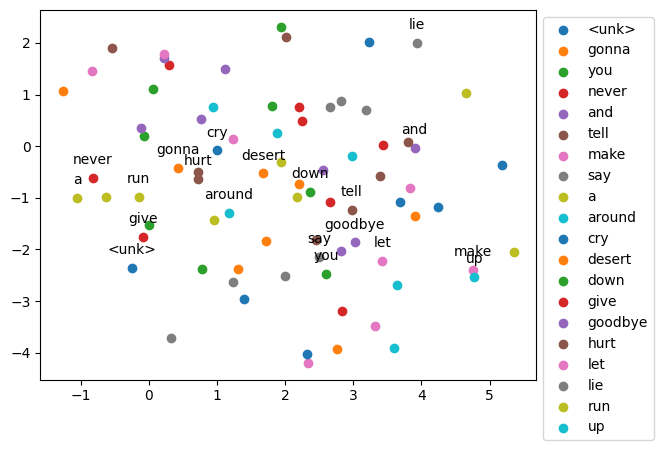

In [86]:
X = lanuage_model.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Perplexity
Perplexity is a measurement used to evaluate the effectiveness of language models or probability models. It provides an indication of how well a model predicts a sample of data or the likelihood of an unseen event. Perplexity is commonly used in natural language processing tasks, such as machine translation, speech recognition, and language generation.

Perplexity is derived from the concept of cross-entropy loss, which measures the dissimilarity between predicted probabilities and actual probabilities. 

$$\text{Cross-Entropy Loss} = -\sum_{i=1}^{N} y_i \ln(p_i)$$
The cross-entropy loss is calculated by taking the negative sum of the products of the true labels $y_i$ and the logarithm of the predicted probabilities $p_i$ over $N$ classes.

Taking the exponential of the mean cross-entropy loss gives us the perplexity value.

$$\text{Perplexity} = e^{\frac{1}{N} \text{Cross-Entropy Loss}}$$


A lower perplexity value indicates that the model is more confident and accurate in predicting the data. Conversely, a higher perplexity suggests that the model is less certain and less accurate in its predictions.

Perplexity can be seen as an estimate of the average number of choices the model has for the next word or event in a sequence. A lower perplexity means that the model is more certain about the next word, while a higher perplexity means that there are more possible choices.
